In [ ]:
import pandas as pd
import numpy as np

# ##################################
from matplotlib import pyplot as plt
from matplotlib import font_manager, rcParams

font_path = "wqy-zenhei.ttc"
font_manager.fontManager.addfont(font_path)

# 2. 获取字体名称
font_prop = font_manager.FontProperties(fname=font_path)
font_name = font_prop.get_name()
print("Loaded font name:", font_name)

# 3. 设置为全局字体
rcParams['font.sans-serif'] = [font_name]
rcParams['axes.unicode_minus'] = False
# #######################################

df = pd.read_csv("./dataset.csv")
# WindNumber	Time	WindSpeed	Power	RotorSpeed
df.columns = ['风机编号', '时间戳', '风速', '功率', '风轮转速']

df["时间戳"] = pd.to_datetime(df["时间戳"])
df = df.sort_values(["风机编号", "时间戳"]).reset_index(drop=True)


# 官方给的每个风机的风轮直径、额定功率、切入风速、切出风速、风轮转速范围
def wheel_diameter(id_):
    # 风轮直径
    if id_==5:return 100.5
    elif id_==11:return 115
    elif id_==12:return 104.8
    else:return 99 
    
def rated_p(id_):
    # 额定功率
    return 2000

def cutin_wind(id_):
    # 切入风速(m/s)
    if id_ == 11:return 2.5
    else:        return 3 
def cutout_wind(id_):
    # 切出风速(m/s)
    if id_==5 or id_==12:return 22
    elif id_==11:        return 19
    else:                return 25
def wheel_speed(id_):
    # 风轮转速范围
    if id_ == 5:return [5.5,19]
    elif id_ == 11:return [5,14]
    elif id_ == 12:return [5.5,17]
    return [8.33,16.8]
    
    
df['风轮直径'] = df['风机编号'].apply(wheel_diameter)
df['额定功率'] = df['风机编号'].apply(rated_p)
df['切入风速'] = df['风机编号'].apply(cutin_wind)
df['切出风速'] = df['风机编号'].apply(cutout_wind)
df['风轮转速范围_min'] = df['风机编号'].apply(lambda x: wheel_speed(x)[0])
df['风轮转速范围_max'] = df['风机编号'].apply(lambda x: wheel_speed(x)[1])

df


Loaded font name: WenQuanYi Zen Hei


,风机编号,时间戳,风速,功率,风轮转速,风轮直径,额定功率,切入风速,切出风速,风轮转速范围_min,风轮转速范围_max
0,1,2017-11-01 00:20:00,4.188333,65.750000,5.779167,99.0,2000,3.0,25,8.33,16.8
1,1,2017-11-01 00:30:00,4.042500,120.700000,8.636500,99.0,2000,3.0,25,8.33,16.8
2,1,2017-11-01 00:40:00,4.137368,135.157895,8.668421,99.0,2000,3.0,25,8.33,16.8
3,1,2017-11-01 00:50:00,4.274737,157.315789,8.727895,99.0,2000,3.0,25,8.33,16.8
4,1,2017-11-01 01:00:00,4.108947,129.894737,8.656842,99.0,2000,3.0,25,8.33,16.8
...,...,...,...,...,...,...,...,...,...,...,...
497832,12,2019-12-31 23:00:00,7.054167,1097.633333,14.650750,104.8,2000,3.0,22,5.50,17.0
497833,12,2019-12-31 23:10:00,7.401833,1093.031667,14.823250,104.8,2000,3.0,22,5.50,17.0
497834,12,2019-12-31 23:20:00,7.754333,1217.640000,15.036750,104.8,2000,3.0,22,5.50,17.0
497835,12,2019-12-31 23:30:00,7.366667,1115.886667,14.817500,104.8,2000,3.0,22,5.50,17.0


In [25]:
def view_speed_power(
    df,
    normal_df,
    abnormal_df,
    nrows=4,
    ncols=3,
    figsize=(18, 12)
):

    wt_ids = sorted(df['风机编号'].unique())
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=figsize)
    axes = axes.flatten()

    for i, wt_id in enumerate(wt_ids):
        g = df[df['风机编号'] == wt_id]
        ax = axes[i]

        normal = normal_df[normal_df.index.isin(g.index)]
        abnormal = abnormal_df[abnormal_df.index.isin(g.index)]

        ax.scatter(
            normal['风速'], normal['功率'],
            s=1, alpha=0.5, label='正常'
        )

        ax.scatter(
            abnormal['风速'], abnormal['功率'],
            s=1, alpha=0.5, label='异常'
        )

        ax.axhline(
            y=g['额定功率'].iloc[0],
            linestyle='--',
            label='额定功率'
        )
        cutin = g['切入风速'].iloc[0]
        cutout = g['切出风速'].iloc[0]

        ax.axvline(
            x=cutin,
            linestyle='--',
            color='green',
            label='切入风速'
        )

        ax.axvline(
            x=cutout,
            linestyle='--',
            color='red',
            label='切出风速'
        )
                

        ax.set_title(f'风机 {wt_id}')
        ax.set_xlabel('风速')
        ax.set_ylabel('功率')
        ax.legend(markerscale=5)

    plt.tight_layout()
    plt.show()


In [26]:
def physical_filter(df):
    return df[
        (df['功率'] > 0) &
        (df['功率'] < 1.05 * df['额定功率']) &
        (df['风速'] > df['切入风速']) &
        (df['风速'] < df['切出风速']) &
        (df['风轮转速'] > df['风轮转速范围_min']) &
        (df['风轮转速'] < df['风轮转速范围_max'])
    ].copy()


In [27]:
from scipy.optimize import curve_fit

def sigmoid(v, a, b, c):
    return a / (1 + np.exp(-b * (v - c)))


In [28]:
def fit_sigmoid_robust(df):
    if len(df) < 50:
        return None

    v = df['风速'].values
    p = df['功率'].values

    p0 = [
        df['额定功率'].iloc[0],
        1.0,
        np.median(v)
    ]

    try:
        popt, _ = curve_fit(sigmoid, v, p, p0=p0, maxfev=200000)
    except Exception:
        return None

    # 第二阶段：剔除大残差点
    residual = p - sigmoid(v, *popt)
    mu = np.mean(residual)
    sigma = np.std(residual) + 1e-6

    mask = (residual > mu - 3 * sigma) & (residual < mu + 3 * sigma)

    try:
        popt_refined, _ = curve_fit(
            sigmoid,
            v[mask], p[mask],
            p0=popt,
            maxfev=200000
        )
        return popt_refined
    except Exception:
        return popt


In [29]:
def build_turbine_baseline(df):
    df_clean = physical_filter(df)
    results = []

    for wt_id, g in df_clean.groupby('风机编号'):
        params = fit_sigmoid_robust(g)
        if params is None:
            continue

        a, b, c = params
        results.append({
            '风机编号': wt_id,
            'a_base': a,
            'b_base': b,
            'c_base': c,
            '样本点数': len(g)
        })

    return pd.DataFrame(results)
wt_base_df = build_turbine_baseline(df)
wt_base_df

,风机编号,a_base,b_base,c_base,样本点数
0,1,2042.248852,0.627859,8.473219,24080
1,2,1035.523947,0.810330,6.964355,23480
2,3,1590.023384,0.451984,10.088269,25653
3,4,2071.681964,0.659147,8.328311,29292
4,5,2042.558975,0.699918,7.972806,28689
5,6,892.495139,0.587120,8.336130,26703
6,7,1974.326481,0.495837,9.360733,25737
7,8,2003.383808,0.624456,8.567606,25532
8,9,1666.441643,0.650633,8.226904,29085
9,10,2129.876164,0.598501,8.531716,28847


In [30]:
df = df.merge(wt_base_df, on='风机编号', how='left')

df['功率_pred_base'] = sigmoid(
    df['风速'],
    df['a_base'],
    df['b_base'],
    df['c_base']
)

df['residual'] = df['功率'] - df['功率_pred_base']
df

,风机编号,时间戳,风速,功率,风轮转速,风轮直径,额定功率,切入风速,切出风速,风轮转速范围_min,风轮转速范围_max,a_base,b_base,c_base,样本点数,功率_pred_base,residual
0,1,2017-11-01 00:20:00,4.188333,65.750000,5.779167,99.0,2000,3.0,25,8.33,16.8,2042.248852,0.627859,8.473219,24080,129.780597,-64.030597
1,1,2017-11-01 00:30:00,4.042500,120.700000,8.636500,99.0,2000,3.0,25,8.33,16.8,2042.248852,0.627859,8.473219,24080,119.087465,1.612535
2,1,2017-11-01 00:40:00,4.137368,135.157895,8.668421,99.0,2000,3.0,25,8.33,16.8,2042.248852,0.627859,8.473219,24080,125.945566,9.212329
3,1,2017-11-01 00:50:00,4.274737,157.315789,8.727895,99.0,2000,3.0,25,8.33,16.8,2042.248852,0.627859,8.473219,24080,136.531882,20.783908
4,1,2017-11-01 01:00:00,4.108947,129.894737,8.656842,99.0,2000,3.0,25,8.33,16.8,2042.248852,0.627859,8.473219,24080,123.853161,6.041575
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
497832,12,2019-12-31 23:00:00,7.054167,1097.633333,14.650750,104.8,2000,3.0,22,5.50,17.0,1929.369735,0.799194,6.946225,19032,1006.269062,91.364271
497833,12,2019-12-31 23:10:00,7.401833,1093.031667,14.823250,104.8,2000,3.0,22,5.50,17.0,1929.369735,0.799194,6.946225,19032,1138.400181,-45.368514
497834,12,2019-12-31 23:20:00,7.754333,1217.640000,15.036750,104.8,2000,3.0,22,5.50,17.0,1929.369735,0.799194,6.946225,19032,1265.804396,-48.164396
497835,12,2019-12-31 23:30:00,7.366667,1115.886667,14.817500,104.8,2000,3.0,22,5.50,17.0,1929.369735,0.799194,6.946225,19032,1125.251124,-9.364457


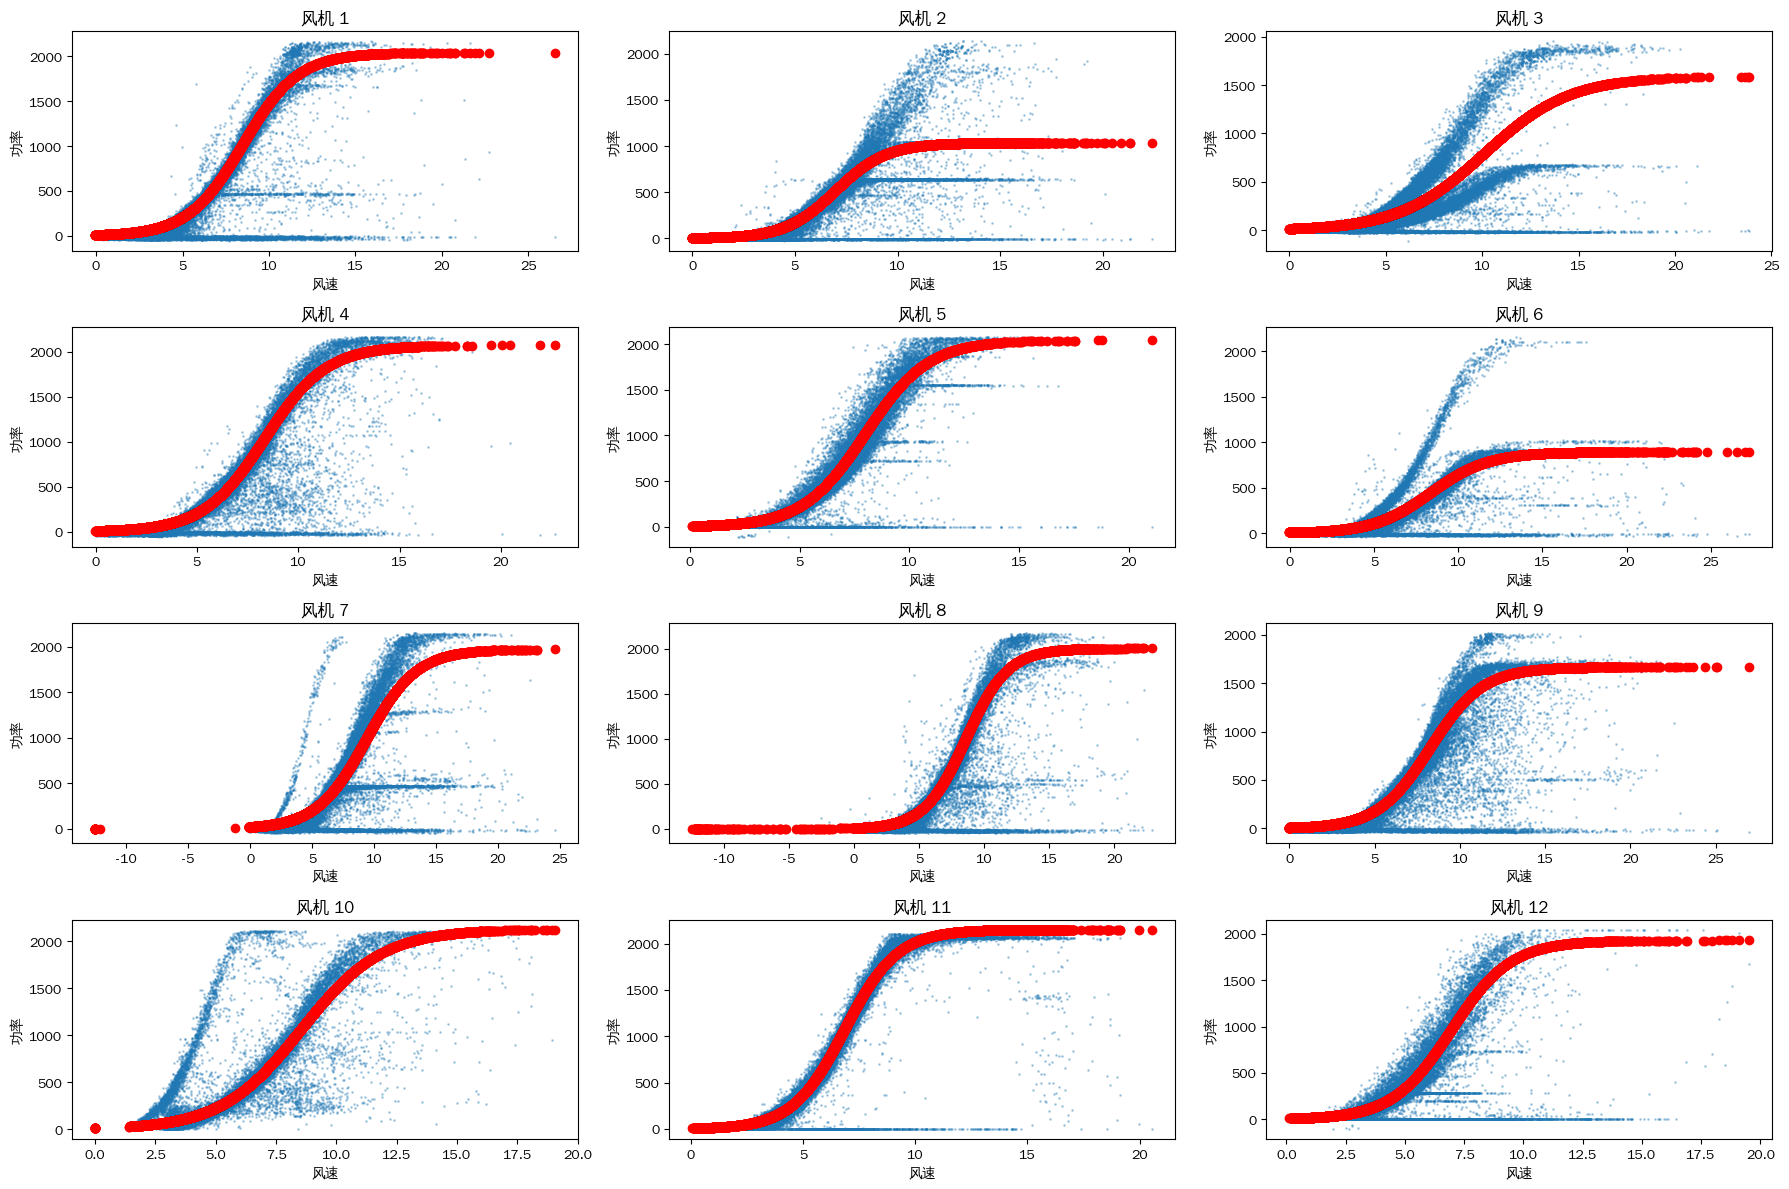

In [31]:

wt_ids = sorted(df['风机编号'].unique())
fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(18, 12))
axes = axes.flatten()
for i, wind_turbine in enumerate(wt_ids):
    ax = axes[i]    
    ax.scatter(
        x=df[df['风机编号'] == wind_turbine]['风速'],
        y=df[df['风机编号'] == wind_turbine]['功率'],
        s=1, alpha=0.3
    )
    ax.scatter(
        x=df[df['风机编号'] == wind_turbine]['风速'],
        y=df[df['风机编号'] == wind_turbine]['功率_pred_base'],
        color='red'
    )
    ax.set_title(f'风机 {wind_turbine}')
    ax.set_xlabel('风速')
    ax.set_ylabel('功率')
plt.tight_layout()



In [ ]:
# 按照风速bin重新计算

df['is_outlier_mad'] = False

df['wind_bin'] = (df['风速'] // 0.5) * 0.5

for (wt_id, wbin), g in df.groupby(['风机编号', 'wind_bin']):
    med = g['residual'].median()
    mad = (g['residual'] - med).abs().median()
    k = 3
    lb = med - k * 1.4826 * mad
    ub = med + k * 1.4826 * mad
    out_idx = g.index[~g['residual'].between(lb, ub)]
    df.loc[out_idx, 'is_outlier_mad'] = True



print(f"异常点数量: {df['is_outlier_mad'].sum()}")
print(df.shape)


异常点数量: 35618
(497837, 19)


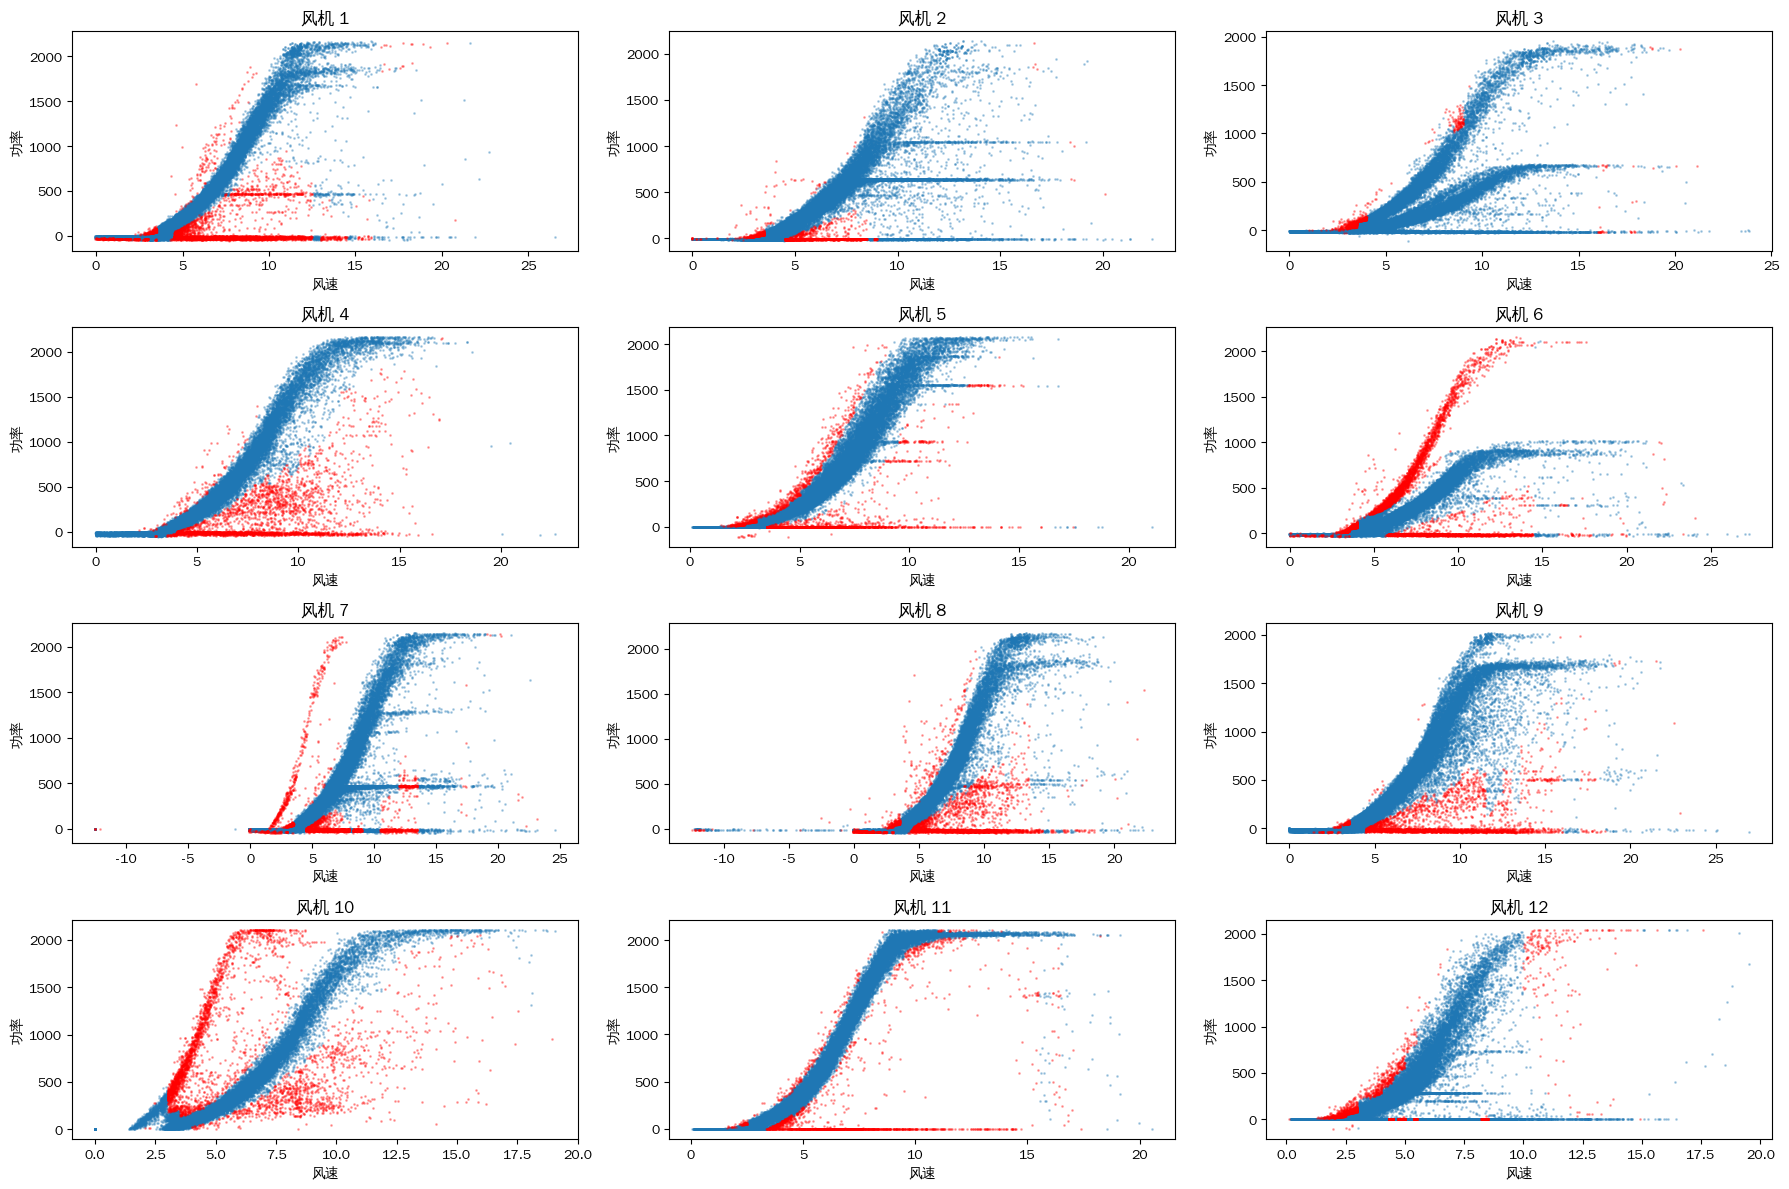

In [33]:

wt_ids = sorted(df['风机编号'].unique())
fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(18, 12))
axes = axes.flatten()
for i, wind_turbine in enumerate(wt_ids):
    ax = axes[i]    
    g = df[df['风机编号'] == wind_turbine].copy()
    normal_points = g[~g['is_outlier_mad']]
    outlier_points = g[g['is_outlier_mad']]
    ax.scatter(
        x=normal_points['风速'],
        y=normal_points['功率'],
        s=1, alpha=0.3,
        label='正常'
    )
    ax.scatter(
        x=outlier_points['风速'],
        y=outlier_points['功率'],
        s=1, alpha=0.3,
        color='red',
        label='异常'
    )
    ax.set_title(f'风机 {wind_turbine}')
    ax.set_xlabel('风速')
    ax.set_ylabel('功率')
plt.tight_layout()

